# Statistical Analysis of Restaurant Tipping Behavior


**Dataset:** Seaborn Restaurant Tips Dataset  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy, Statsmodels  
testing, multiple linear regression, and regression diagnostics.

The major questions are:

1. Does the average tip differ between smokers and non-smokers?
2. Does the average tip differ across days of the week?
3. How strongly does the total bill predict the tip amount?
4. Do party size, smoking status, meal time, and day provide additional explanatory power?
5. Does the fitted OLS model satisfy the major regression assumptions?


## 1. Import Required Libraries

In [39]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')


## 2. Load the Dataset

The Seaborn `tips` dataset contains information about restaurant bills and tips. It includes quantitative variables such as `total_bill`, `tip`, and `size`, along with categorical variables such as `sex`, `smoker`, `day`, and `time`.

In [40]:
df = sns.load_dataset('tips')

print('Dataset loaded successfully.')
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

display(df.head())

Dataset loaded successfully.
Rows: 244
Columns: 7


,total_bill,tip,sex,smoker,day,time,size
0,16.9900,1.0100,Female,No,Sun,Dinner,2
1,10.3400,1.6600,Male,No,Sun,Dinner,3
2,21.0100,3.5000,Male,No,Sun,Dinner,3
3,23.6800,3.3100,Male,No,Sun,Dinner,2
4,24.5900,3.6100,Female,No,Sun,Dinner,4


## 3. Dataset Description

In [41]:
description = pd.DataFrame({
    'Variable': df.columns,
    'Data Type': df.dtypes.astype(str).values,
    'Description': [
        'Total bill amount in dollars',
        'Tip amount in dollars',
        'Customer sex',
        'Whether the customer is a smoker',
        'Day of the week',
        'Lunch or dinner',
        'Number of people in the party'
    ]
})
display(description)

,Variable,Data Type,Description
0,total_bill,float64,Total bill amount in dollars
1,tip,float64,Tip amount in dollars
2,sex,category,Customer sex
3,smoker,category,Whether the customer is a smoker
4,day,category,Day of the week
5,time,category,Lunch or dinner
6,size,int64,Number of people in the party


## 4. Data Inspection and Cleaning

Before statistical analysis, we check for missing values, duplicate observations, and unusual data types.

In [42]:
print('Dataset information:')
df.info()

print('\nMissing values:')
display(df.isnull().sum().to_frame('Missing Values'))

print(f'\nDuplicate rows: {df.duplicated().sum()}')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB

Missing values:


,Missing Values
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0



Duplicate rows: 1


In [43]:
# Remove duplicate rows if any are present.
df = df.drop_duplicates().reset_index(drop=True)

print(f'Dataset size after duplicate handling: {df.shape}')
display(df.describe(include='all').T)

Dataset size after duplicate handling: (243, 7)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
total_bill,243.0000,NaN,NaN,NaN,19.8139,8.9101,3.0700,13.3800,17.8100,24.1750,50.8100
tip,243.0000,NaN,NaN,NaN,3.0024,1.3850,1.0000,2.0000,2.9200,3.5750,10.0000
sex,243,2,Male,157,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoker,243,2,No,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,243,4,Sat,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,243,2,Dinner,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,243.0000,NaN,NaN,NaN,2.5720,0.9524,1.0000,2.0000,2.0000,3.0000,6.0000


### Data Cleaning Conclusion

The dataset is already relatively clean and contains quantitative and categorical variables suitable for statistical analysis. Any duplicate observations are removed before continuing.

## 5. Exploratory Data Analysis

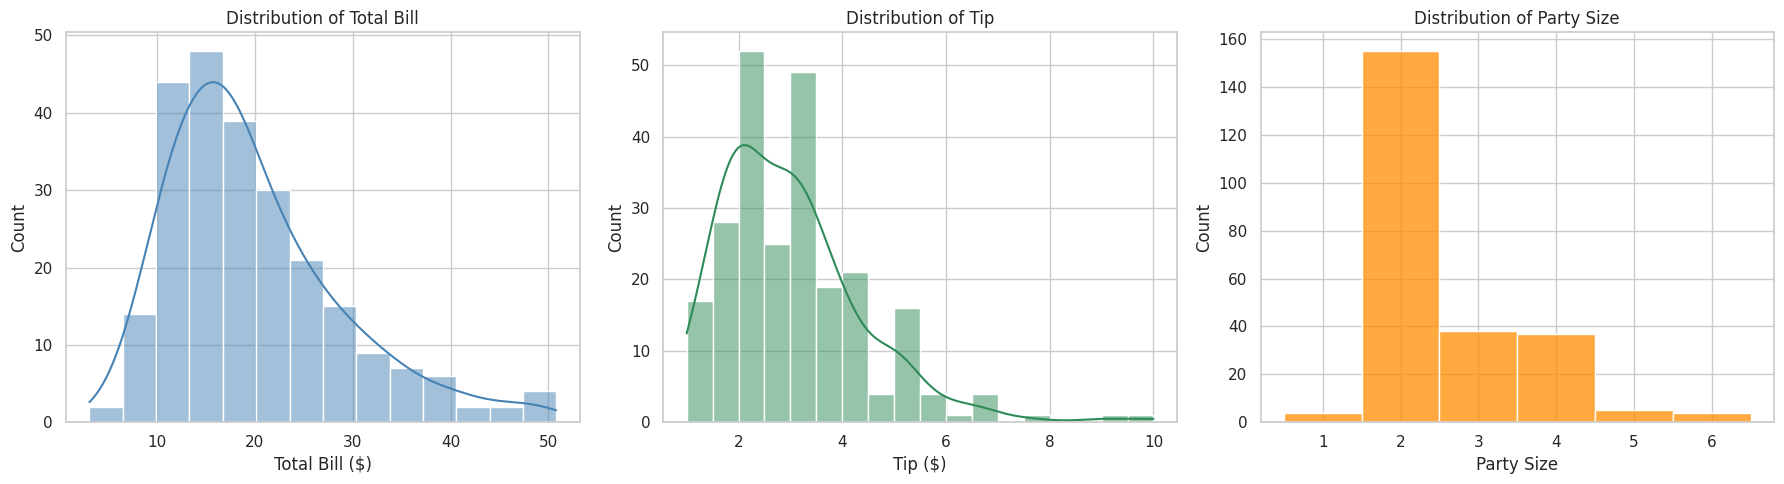

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['total_bill'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Total Bill')
axes[0].set_xlabel('Total Bill ($)')

sns.histplot(df['tip'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of Tip')
axes[1].set_xlabel('Tip ($)')

sns.histplot(df['size'], discrete=True, ax=axes[2], color='darkorange')
axes[2].set_title('Distribution of Party Size')
axes[2].set_xlabel('Party Size')

plt.tight_layout()
plt.show()

## 6. Descriptive Statistics

In [45]:
numeric_summary = df[['total_bill', 'tip', 'size']].describe().T
numeric_summary['median'] = df[['total_bill', 'tip', 'size']].median()
display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,median
total_bill,243.0000,19.8139,8.9101,3.0700,13.3800,17.8100,24.1750,50.8100,17.8100
tip,243.0000,3.0024,1.3850,1.0000,2.0000,2.9200,3.5750,10.0000,2.9200
size,243.0000,2.5720,0.9524,1.0000,2.0000,2.0000,3.0000,6.0000,2.0000


### Categorical Variable Frequencies

In [46]:
categorical_columns = ['sex', 'smoker', 'day', 'time']

for col in categorical_columns:
    print(f'\n{col.upper()}')
    display(df[col].value_counts().to_frame('Count'))


SEX


,Count
sex,
Male,157
Female,86



SMOKER


,Count
smoker,
No,151
Yes,92



DAY


,Count
day,
Sat,87
Sun,76
Thur,61
Fri,19



TIME


,Count
time,
Dinner,176
Lunch,67


## 7. Relationship Between Total Bill and Tip

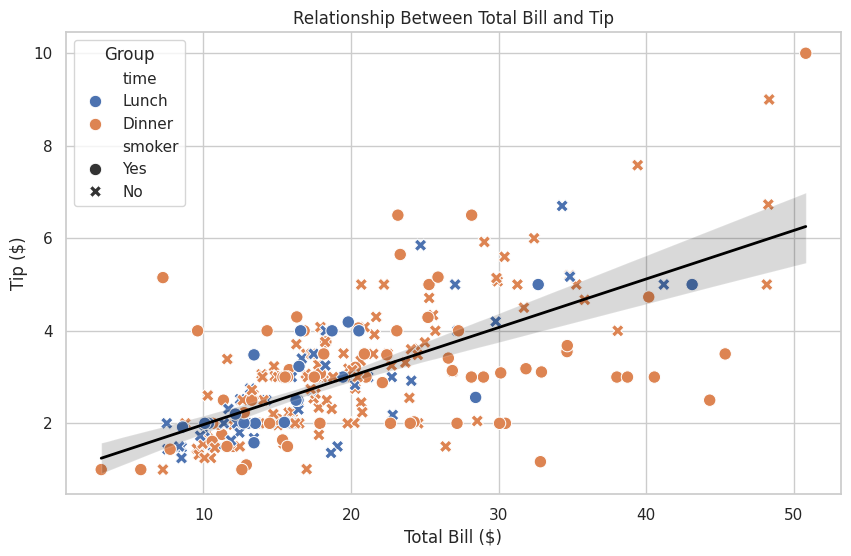

In [47]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', style='smoker', s=80)
sns.regplot(data=df, x='total_bill', y='tip', scatter=False, color='black', line_kws={'linewidth': 2})
plt.title('Relationship Between Total Bill and Tip')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.legend(title='Group')
plt.show()

In [48]:
pearson_r, pearson_p = stats.pearsonr(df['total_bill'], df['tip'])
spearman_rho, spearman_p = stats.spearmanr(df['total_bill'], df['tip'])

print(f'Pearson correlation: r = {pearson_r:.4f}, p-value = {pearson_p:.6f}')
print(f'Spearman correlation: rho = {spearman_rho:.4f}, p-value = {spearman_p:.6f}')

Pearson correlation: r = 0.6750, p-value = 0.000000
Spearman correlation: rho = 0.6774, p-value = 0.000000


### Interpretation

Pearson correlation measures the strength of the linear relationship between total bill and tip, while Spearman correlation measures the strength of a monotonic relationship. The two measures provide complementary evidence about the association between these variables.

## 8. Hypothesis Test 1 — Two-Sample t-Test

### Question

**Is the mean tip amount significantly different between smokers and non-smokers?**

**Null hypothesis (H₀):** The mean tip is equal for smokers and non-smokers.

**Alternative hypothesis (H₁):** The mean tip differs between smokers and non-smokers.

We use Welch's independent two-sample t-test because it does not require the two groups to have equal variances.

In [49]:
smoker_tips = df.loc[df['smoker'] == 'Yes', 'tip']
non_smoker_tips = df.loc[df['smoker'] == 'No', 'tip']

t_stat, t_pvalue = stats.ttest_ind(
    smoker_tips,
    non_smoker_tips,
    equal_var=False
)

print(f'Smokers mean tip: ${smoker_tips.mean():.4f}')
print(f'Non-smokers mean tip: ${non_smoker_tips.mean():.4f}')
print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {t_pvalue:.6f}')

alpha = 0.05
if t_pvalue < alpha:
    print('Conclusion: Reject H₀. There is statistically significant evidence of a difference in mean tips.')
else:
    print('Conclusion: Fail to reject H₀. There is insufficient evidence of a difference in mean tips.')

Smokers mean tip: $3.0197
Non-smokers mean tip: $2.9919
t-statistic: 0.1508
p-value: 0.880274
Conclusion: Fail to reject H₀. There is insufficient evidence of a difference in mean tips.


### Effect Size — Cohen's d

In [50]:
n1 = len(smoker_tips)
n2 = len(non_smoker_tips)
s1 = smoker_tips.std(ddof=1)
s2 = non_smoker_tips.std(ddof=1)

pooled_sd = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
cohens_d = (smoker_tips.mean() - non_smoker_tips.mean()) / pooled_sd
print(f"Cohen's d: {cohens_d:.4f}")

Cohen's d: 0.0200


## 9. Hypothesis Test 2 — One-Way ANOVA

### Question

**Does the average tip amount differ across days of the week?**

**H₀:** The mean tip is the same across all days.

**H₁:** At least one day's mean tip differs from another.

A one-way ANOVA is appropriate because we are comparing the means of more than two independent groups.

In [51]:
day_groups = [group['tip'].values for _, group in df.groupby('day')]
anova_stat, anova_pvalue = stats.f_oneway(*day_groups)
print(f'ANOVA F-statistic: {anova_stat:.4f}')
print(f'p-value: {anova_pvalue:.6f}')

if anova_pvalue < alpha:
    print('Conclusion: Reject H₀. At least one day has a significantly different mean tip.')
else:
    print('Conclusion: Fail to reject H₀. There is insufficient evidence that mean tips differ by day.')

ANOVA F-statistic: 1.5983
p-value: 0.190449
Conclusion: Fail to reject H₀. There is insufficient evidence that mean tips differ by day.


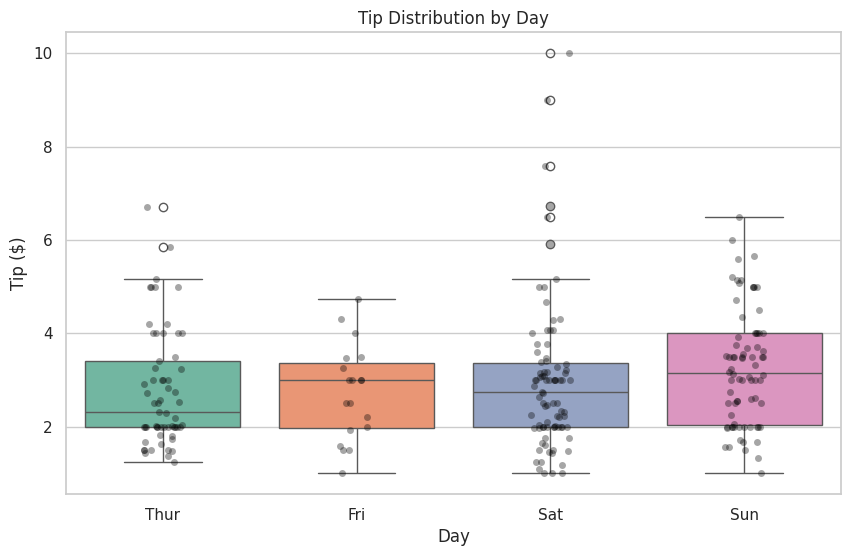

In [52]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='day', y='tip', hue='day', palette='Set2', legend=False)
sns.stripplot(data=df, x='day', y='tip', color='black', alpha=0.35, jitter=True)
plt.title('Tip Distribution by Day')
plt.xlabel('Day')
plt.ylabel('Tip ($)')
plt.show()

## 10. Non-Parametric Test — Kruskal-Wallis Test

To complement ANOVA, we perform the Kruskal-Wallis test. This is a non-parametric alternative that compares the distributions/ranks of multiple independent groups and does not require normally distributed observations.

In [53]:
kruskal_stat, kruskal_pvalue = stats.kruskal(*day_groups)
print(f'Kruskal-Wallis H-statistic: {kruskal_stat:.4f}')
print(f'p-value: {kruskal_pvalue:.6f}')

if kruskal_pvalue < alpha:
    print('Conclusion: Reject H₀. The distributions of tips are not identical across all days.')
else:
    print('Conclusion: Fail to reject H₀. There is insufficient evidence of a difference across days.')

Kruskal-Wallis H-statistic: 8.2812
p-value: 0.040543
Conclusion: Reject H₀. The distributions of tips are not identical across all days.


## 11. Multiple Linear Regression Using OLS

We now model the tip amount as a function of total bill, party size, smoking status, meal time, and day.

The model is:

$$
Tip = β₀ + β₁TotalBill + β₂Size + β₃Smoker + β₄Time + β₅Day + ε
$$

Categorical variables are represented using `C()` in the Statsmodels formula.

In [54]:
model = smf.ols(
    formula='tip ~ total_bill + size + C(smoker) + C(time) + C(day)',
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.453
Method:                 Least Squares   F-statistic:                     29.64
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           3.68e-29
Time:                        18:00:39   Log-Likelihood:                -346.56
No. Observations:                 243   AIC:                             709.1
Df Residuals:                     235   BIC:                             737.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.6166      0.24

## 12. Regression Coefficient Table

In [55]:
coef_table = pd.DataFrame({
    'Coefficient': model.params,
    'Std Error': model.bse,
    't-statistic': model.tvalues,
    'p-value': model.pvalues,
    'CI Lower': model.conf_int()[0],
    'CI Upper': model.conf_int()[1]
})

display(coef_table)

,Coefficient,Std Error,t-statistic,p-value,CI Lower,CI Upper
Intercept,0.6166,0.2436,2.5309,0.0120,0.1366,1.0965
C(smoker)[T.No],0.0836,0.1474,0.5668,0.5714,-0.2069,0.3740
C(time)[T.Dinner],-0.0679,0.4446,-0.1527,0.8787,-0.9439,0.8081
C(day)[T.Fri],0.1562,0.3942,0.3961,0.6924,-0.6205,0.9328
C(day)[T.Sat],0.0313,0.4704,0.0665,0.9470,-0.8954,0.9580
C(day)[T.Sun],0.1253,0.4706,0.2663,0.7903,-0.8018,1.0524
total_bill,0.0942,0.0096,9.8479,0.0000,0.0754,0.1130
size,0.1765,0.0895,1.9715,0.0498,0.0001,0.3528


## 13. Regression Model Performance

In [56]:
print(f'R-squared: {model.rsquared:.4f}')
print(f'Adjusted R-squared: {model.rsquared_adj:.4f}')
print(f'F-statistic: {model.fvalue:.4f}')
print(f'F-test p-value: {model.f_pvalue:.6f}')

R-squared: 0.4689
Adjusted R-squared: 0.4531
F-statistic: 29.6392
F-test p-value: 0.000000


### Interpretation of the Regression Model

The coefficient of `total_bill` represents the expected change in tip associated with a one-unit increase in total bill, holding the other predictors constant.

The coefficients for categorical variables represent differences relative to their reference categories. Statsmodels automatically chooses reference categories when using treatment coding.

The R-squared value represents the proportion of variation in tip amounts explained by the predictors included in the model. Adjusted R-squared accounts for the number of predictors in the model.

## 14. Predicted Values and Residuals

In [57]:
df['predicted_tip'] = model.fittedvalues
df['residual'] = model.resid

display(df[['tip', 'predicted_tip', 'residual']].head(10))

,tip,predicted_tip,residual
0,1.0100,2.7110,-1.7010
1,1.6600,2.2610,-0.6010
2,3.5000,3.2662,0.2338
3,3.3100,3.3412,-0.0312
4,3.6100,3.7799,-0.1699
5,4.7100,3.8459,0.8641
6,2.0000,1.9367,0.0633
7,3.1200,3.9957,-0.8757
8,1.9600,2.5273,-0.5673
9,3.2300,2.5028,0.7272


## 15. Residual vs Fitted Plot

A residual-vs-fitted plot helps assess linearity and homoscedasticity. Ideally, residuals should be randomly scattered around zero without a strong curve or funnel shape.

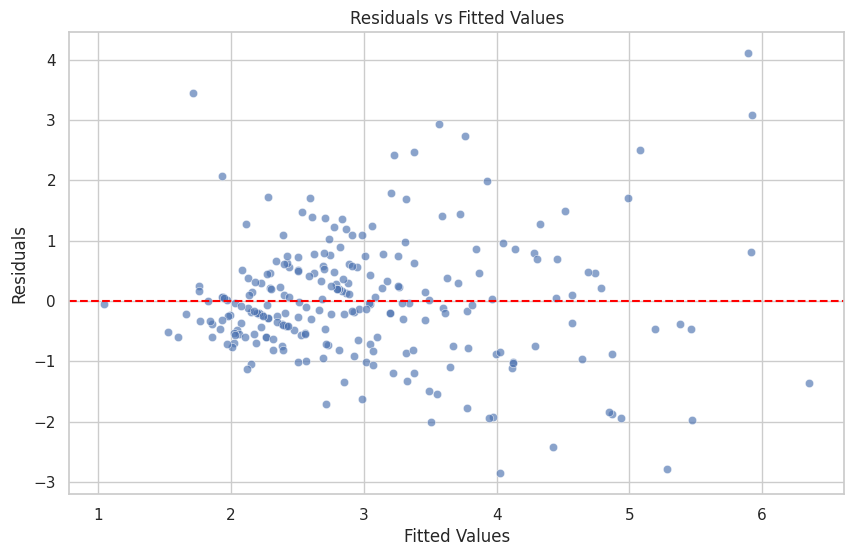

In [58]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=model.fittedvalues, y=model.resid, alpha=0.65)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

## 16. Q-Q Plot for Residual Normality

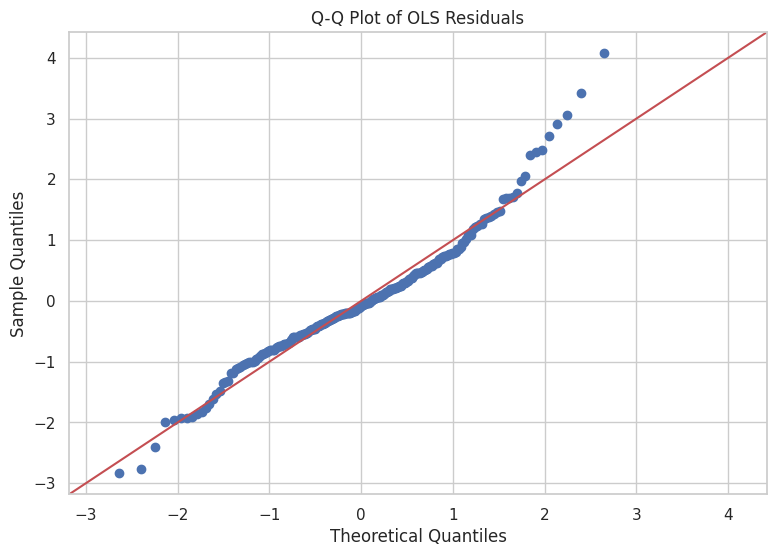

In [59]:
fig = sm.qqplot(model.resid, line='45', fit=True)
fig.set_size_inches(9, 6)
plt.title('Q-Q Plot of OLS Residuals')
plt.show()

## 17. Histogram of Residuals

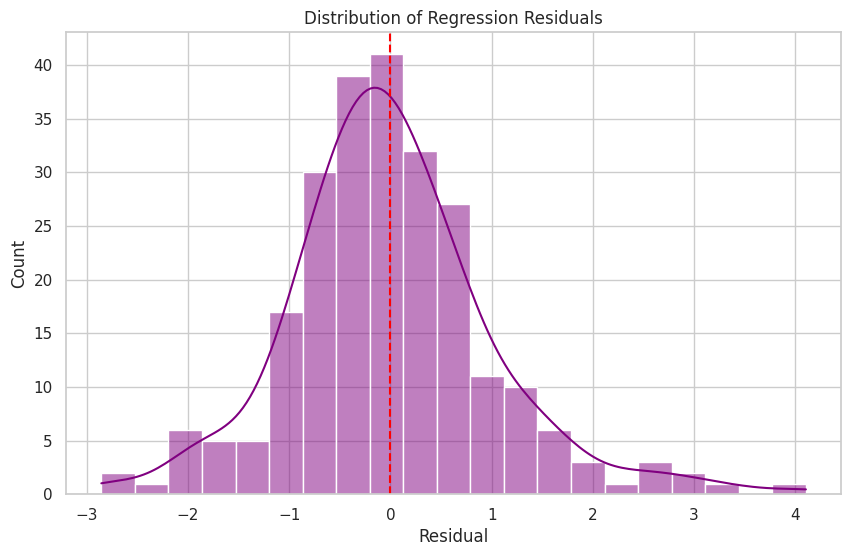

In [60]:
plt.figure(figsize=(10, 6))
sns.histplot(model.resid, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Regression Residuals')
plt.xlabel('Residual')
plt.show()

## 18. Shapiro-Wilk Normality Test

**H₀:** The residuals are normally distributed.

**H₁:** The residuals are not normally distributed.

A p-value below 0.05 provides evidence against normality. However, graphical diagnostics should also be considered because formal normality tests can be sensitive to sample size.

In [61]:
shapiro_stat, shapiro_pvalue = stats.shapiro(model.resid)
print(f'Shapiro-Wilk statistic: {shapiro_stat:.4f}')
print(f'p-value: {shapiro_pvalue:.6f}')

if shapiro_pvalue < alpha:
    print('Conclusion: Reject H₀. The residuals show evidence of non-normality.')
else:
    print('Conclusion: Fail to reject H₀. There is insufficient evidence of non-normality.')

Shapiro-Wilk statistic: 0.9647
p-value: 0.000010
Conclusion: Reject H₀. The residuals show evidence of non-normality.


## 19. Breusch-Pagan Test for Homoscedasticity

The Breusch-Pagan test evaluates whether the residual variance is constant.

**H₀:** The residuals are homoscedastic.

**H₁:** The residual variance is not constant.

In [62]:
bp_test = het_breuschpagan(model.resid, model.model.exog)

bp_labels = [
    'LM Statistic',
    'LM p-value',
    'F Statistic',
    'F p-value'
]

bp_results = pd.Series(bp_test, index=bp_labels)
display(bp_results.to_frame('Value'))

if bp_results['LM p-value'] < alpha:
    print('Conclusion: Reject H₀. There is evidence of heteroscedasticity.')
else:
    print('Conclusion: Fail to reject H₀. There is insufficient evidence of heteroscedasticity.')

,Value
LM Statistic,57.4749
LM p-value,0.0000
F Statistic,10.4003
F p-value,0.0000


Conclusion: Reject H₀. There is evidence of heteroscedasticity.


## 20. Multicollinearity — Variance Inflation Factor (VIF)

VIF measures how strongly a predictor is linearly related to the other predictors.

As a common rule of thumb, VIF values above approximately 5 may indicate potentially concerning multicollinearity, although interpretation depends on the context.

In [63]:
X = model.model.exog
vif_data = pd.DataFrame({
    'Variable': model.model.exog_names,
    'VIF': [variance_inflation_factor(X, i) for i in range(X.shape[1])]
})

display(vif_data)

,Variable,VIF
0,Intercept,13.7464
1,C(smoker)[T.No],1.1842
2,C(time)[T.Dinner],9.1445
3,C(day)[T.Fri],2.5943
4,C(day)[T.Sat],11.7797
5,C(day)[T.Sun],11.0241
6,total_bill,1.6757
7,size,1.6765


## 21. Actual vs Predicted Tips

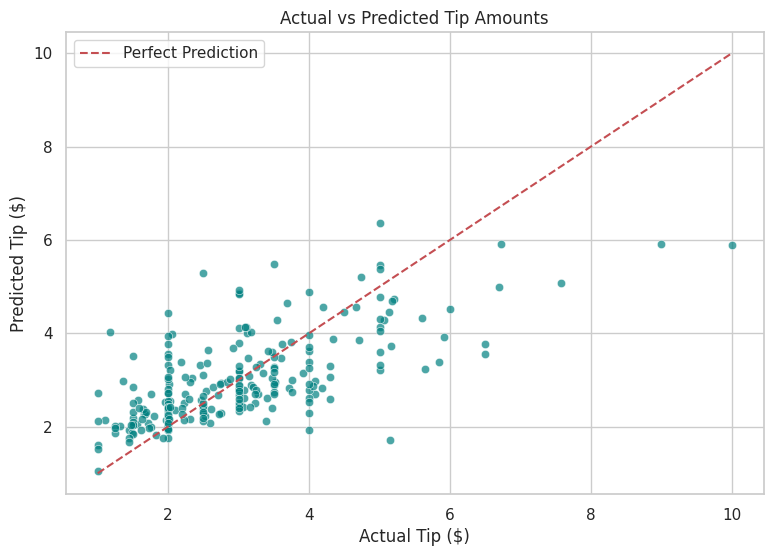

In [64]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x=df['tip'], y=df['predicted_tip'], alpha=0.7, color='teal')

min_value = min(df['tip'].min(), df['predicted_tip'].min())
max_value = max(df['tip'].max(), df['predicted_tip'].max())
plt.plot([min_value, max_value], [min_value, max_value], 'r--', label='Perfect Prediction')

plt.xlabel('Actual Tip ($)')
plt.ylabel('Predicted Tip ($)')
plt.title('Actual vs Predicted Tip Amounts')
plt.legend()
plt.show()

## 22. Influence and Outlier Diagnostics

We use Cook's distance to identify observations that may have a relatively large influence on the fitted regression model.

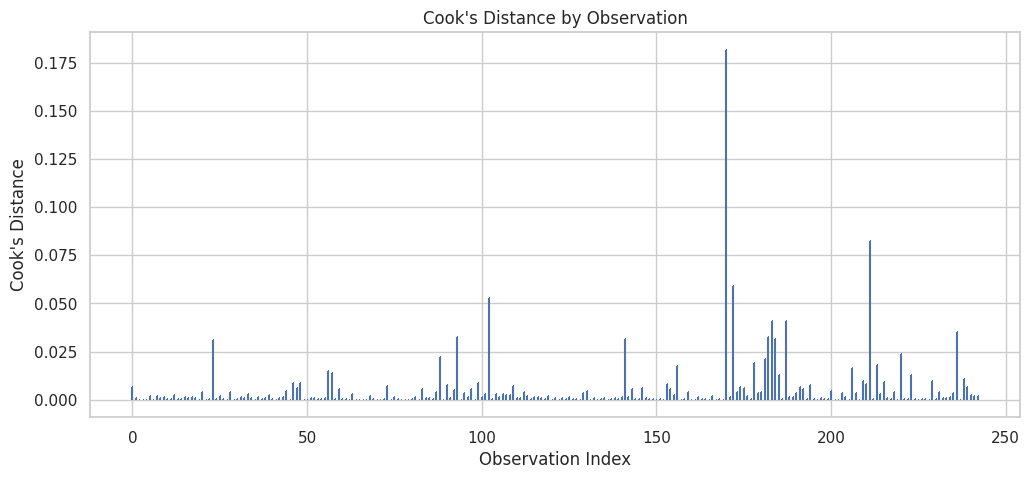

Cook's distance threshold (4/n): 0.0165
Number of observations above threshold: 19
Observation indices: [23, 88, 93, 102, 141, 156, 170, 172, 178, 181, 182, 183, 184, 187, 206, 211, 213, 220, 236]


In [65]:
influence = model.get_influence()
cooks_distance = influence.cooks_distance[0]

plt.figure(figsize=(12, 5))
plt.stem(np.arange(len(cooks_distance)), cooks_distance, markerfmt=',', basefmt=' ')
plt.title("Cook's Distance by Observation")
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance")
plt.show()

threshold = 4 / len(df)
influential = np.where(cooks_distance > threshold)[0]

print(f'Cook\'s distance threshold (4/n): {threshold:.4f}')
print(f'Number of observations above threshold: {len(influential)}')
print(f'Observation indices: {influential.tolist()}')

## 23. Statistical Findings Summary

The following cell creates a compact summary of the major statistical tests performed in this project.

In [66]:
summary_results = pd.DataFrame({
    'Test': [
        'Pearson Correlation',
        'Welch Two-Sample t-Test',
        'One-Way ANOVA',
        'Kruskal-Wallis Test',
        'Shapiro-Wilk Test',
        'Breusch-Pagan Test'
    ],
    'Statistic': [
        pearson_r,
        t_stat,
        anova_stat,
        kruskal_stat,
        shapiro_stat,
        bp_results['LM Statistic']
    ],
    'p-value': [
        pearson_p,
        t_pvalue,
        anova_pvalue,
        kruskal_pvalue,
        shapiro_pvalue,
        bp_results['LM p-value']
    ]
})

display(summary_results)

,Test,Statistic,p-value
0,Pearson Correlation,0.6750,0.0000
1,Welch Two-Sample t-Test,0.1508,0.8803
2,One-Way ANOVA,1.5983,0.1904
3,Kruskal-Wallis Test,8.2812,0.0405
4,Shapiro-Wilk Test,0.9647,0.0000
5,Breusch-Pagan Test,57.4749,0.0000


## Overall Conclusions

### Exploratory Analysis

The exploratory analysis investigates how restaurant tips vary with bill amount, party size, smoking status, day, and meal time. Visualizations show the relationships and distributions before formal statistical modeling.

### Hypothesis Testing

The Welch two-sample t-test evaluates whether smokers and non-smokers have different mean tip amounts. One-way ANOVA evaluates whether mean tips differ across days, while the Kruskal-Wallis test provides a non-parametric comparison across the same groups.

### Regression

The OLS model estimates the relationship between tip amount and several explanatory variables simultaneously. This allows the effect of total bill to be evaluated while controlling for other characteristics.

### Diagnostics

Residual-vs-fitted plots, Q-Q plots, the Shapiro-Wilk test, the Breusch-Pagan test, VIF, and Cook's distance are used to evaluate the reliability of the regression model.

The numerical results generated above should be used in the final written report rather than relying on predetermined values. Statistical conclusions should be based on the calculated p-values, effect sizes, regression coefficients, and diagnostic plots.